In [1]:
# Enable auto-reload for development
%load_ext autoreload
%autoreload 2
import sys
import os

# Add scripts directory to path
sys.path.append(os.path.abspath("../../scripts"))

# Import modules
import data_pipeline
import plots


In [2]:
data_folder = "../../data/04-03-24/"

channels = [
      f[:-4] for f in os.listdir(data_folder)
      if f.endswith('.csv')
]
    
for c in channels:
      df = data_pipeline.load_single_channel(data_folder, c)
      plots.nyquist(df, title_prefix=c)


KeyError: 'Im(Z)/Ohm'

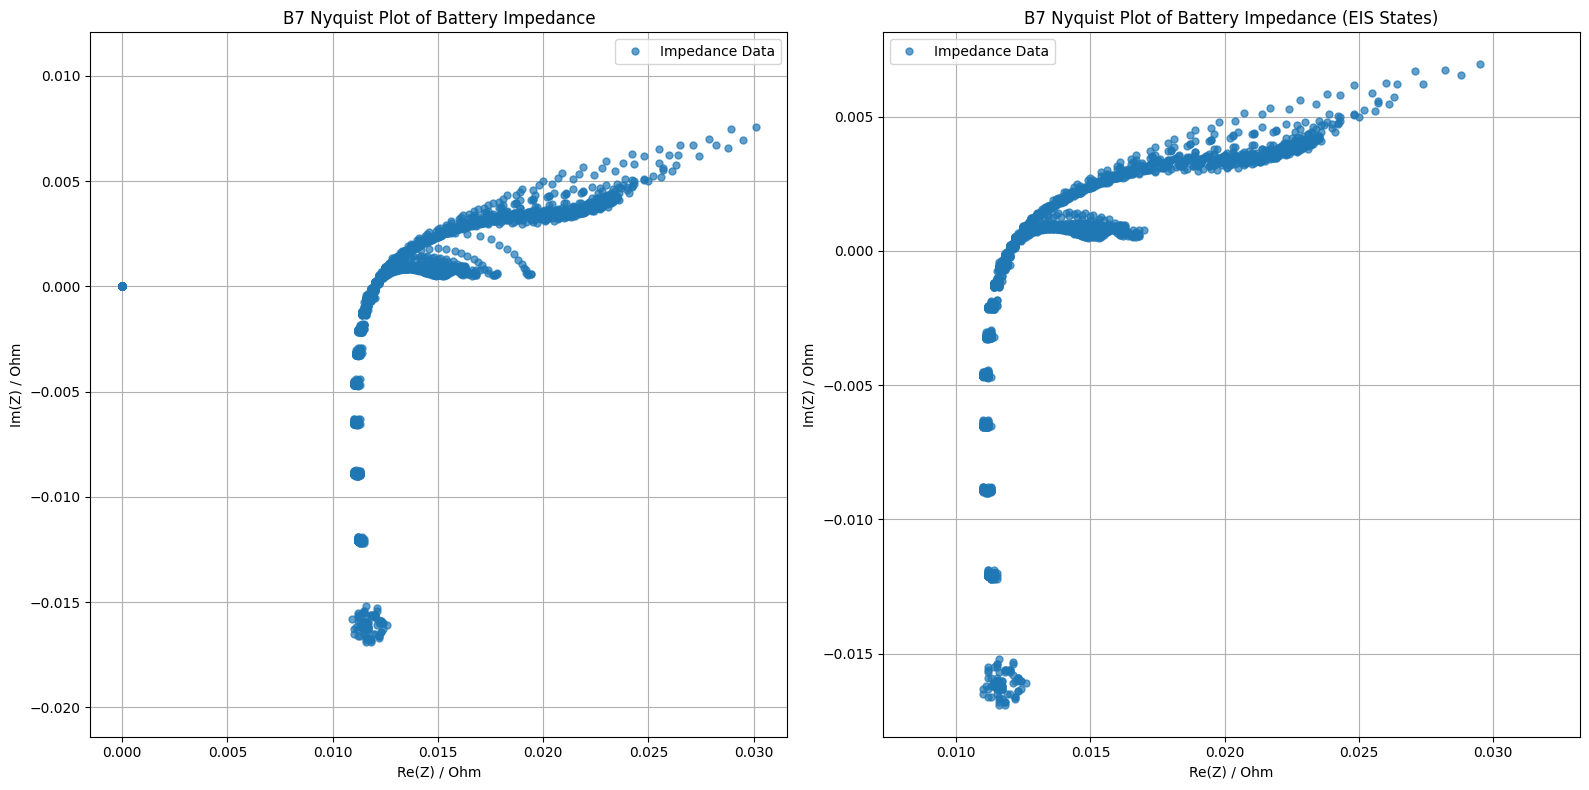

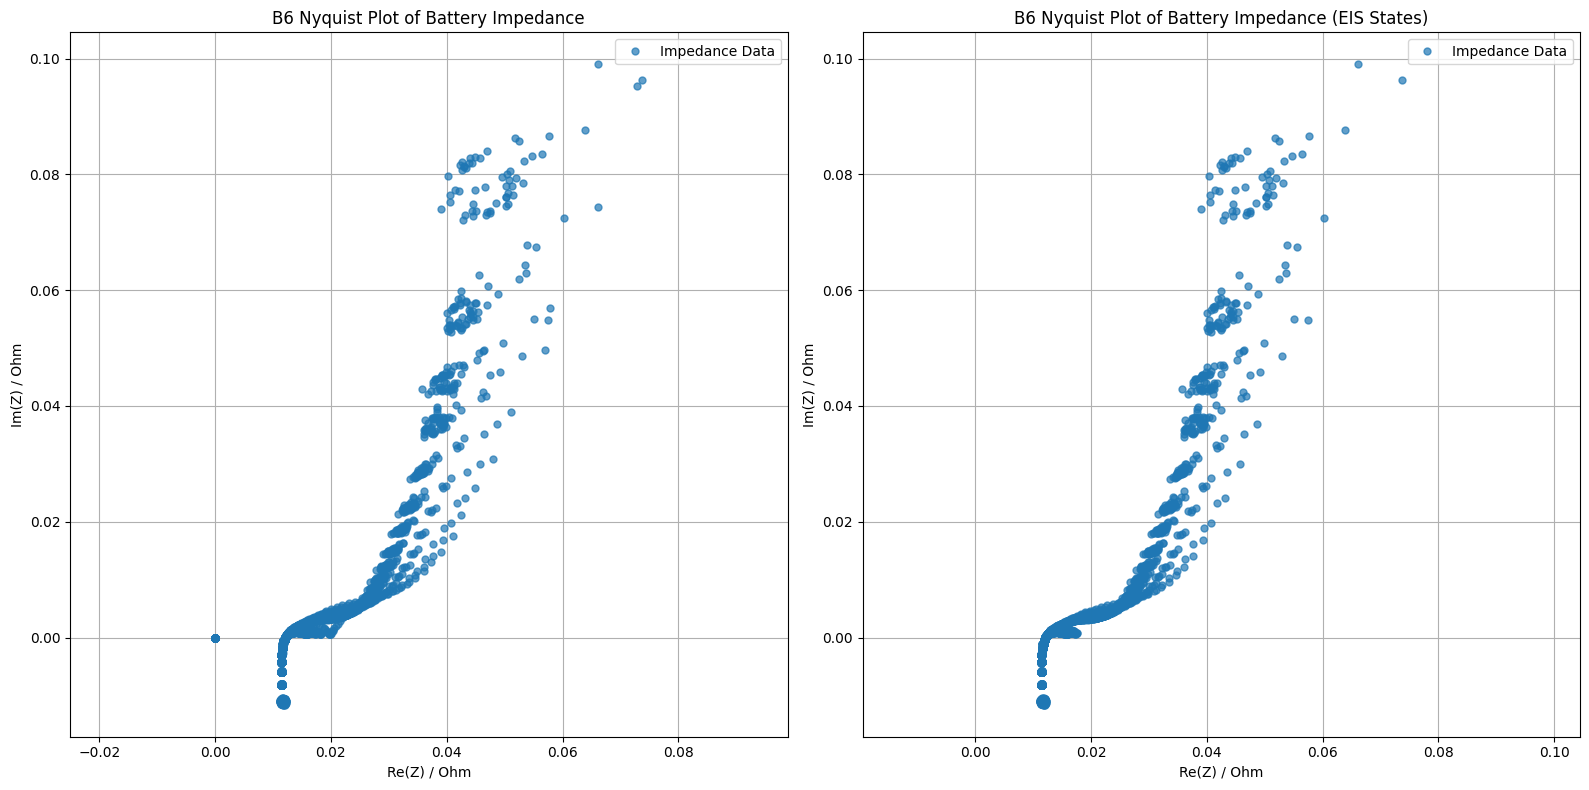

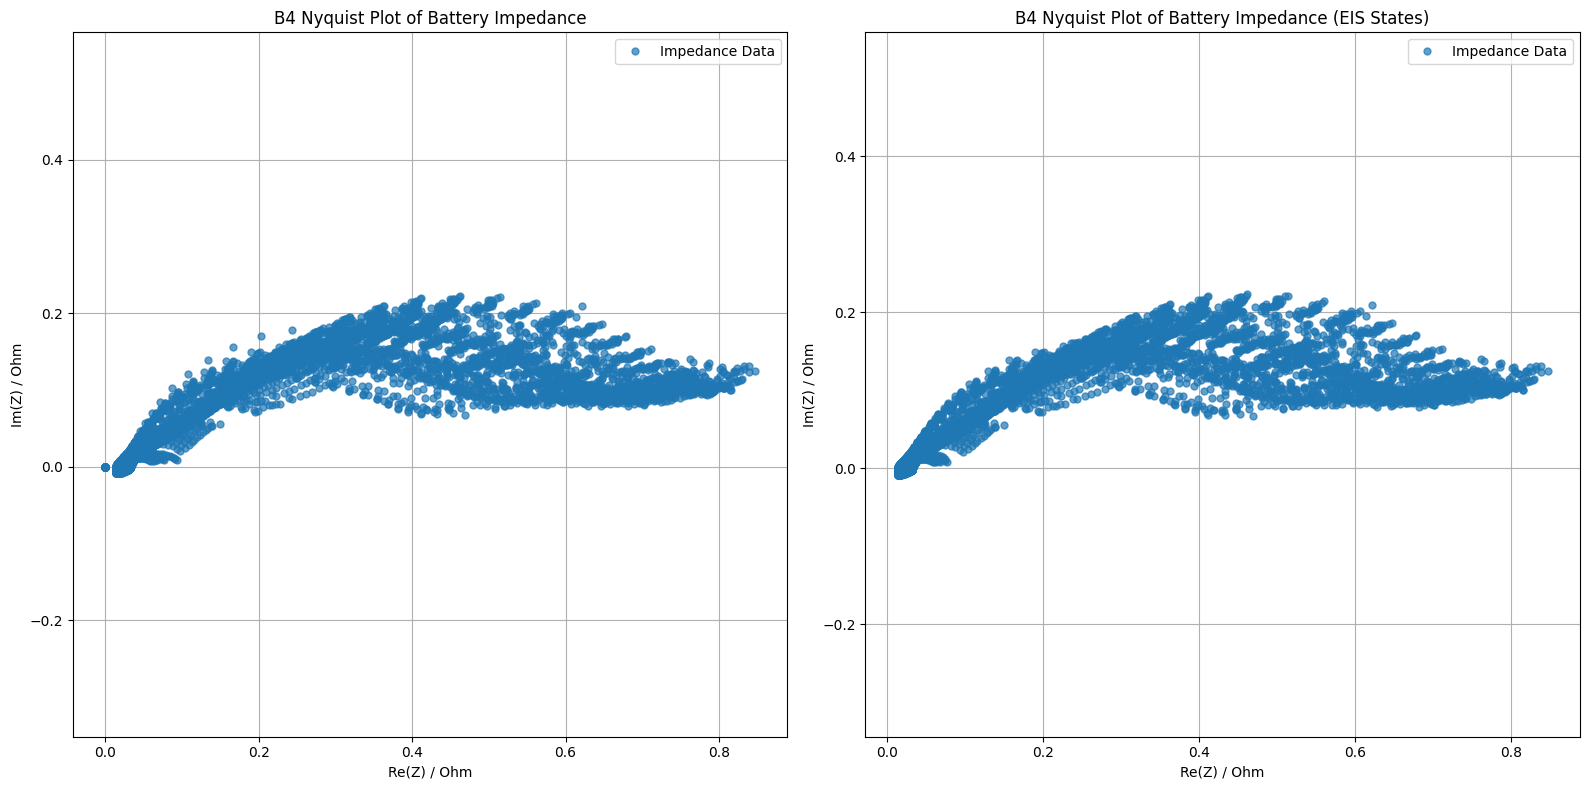

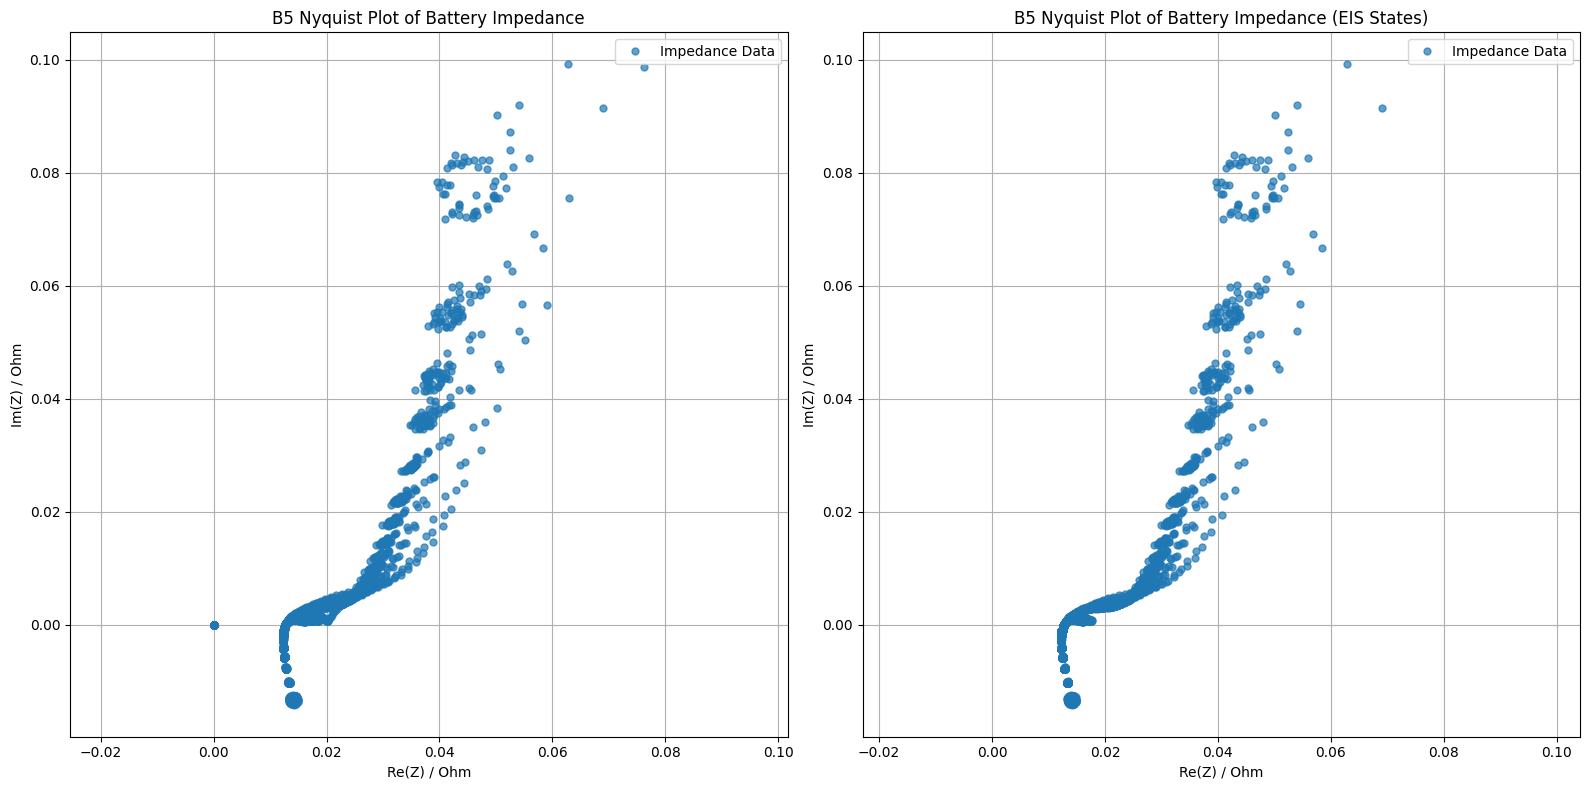

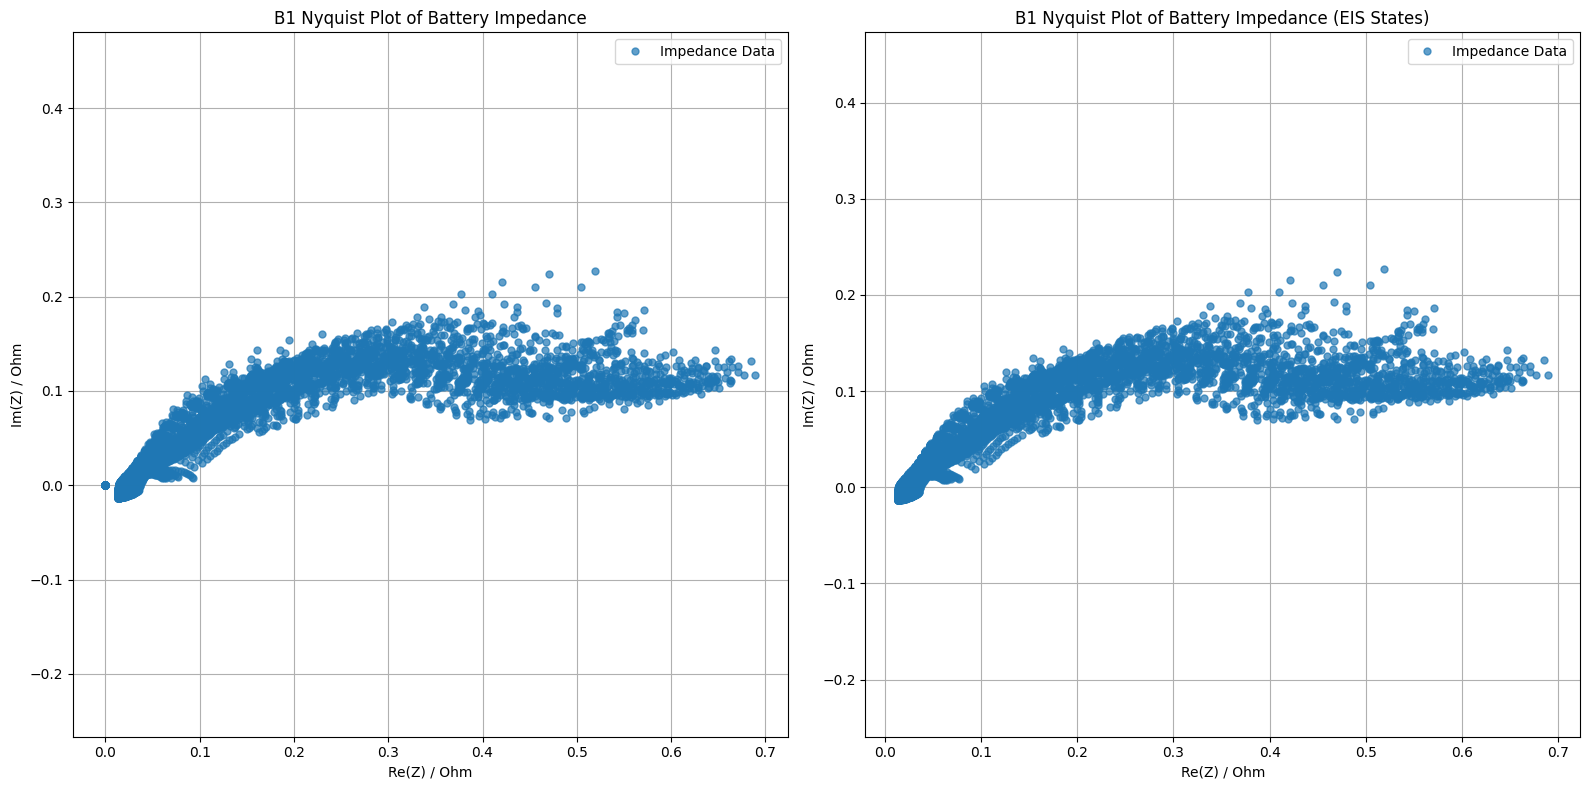

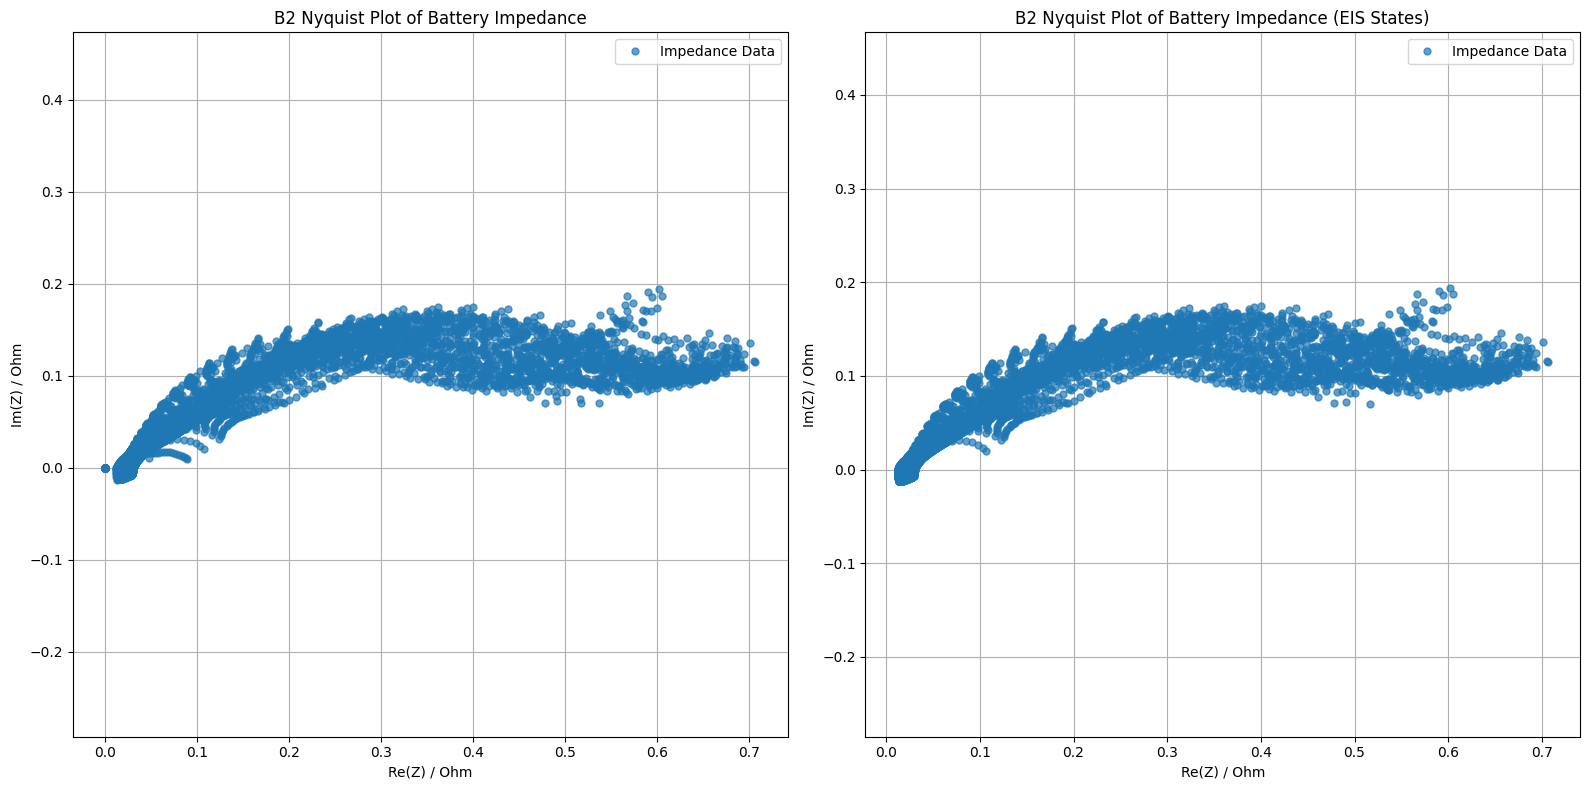

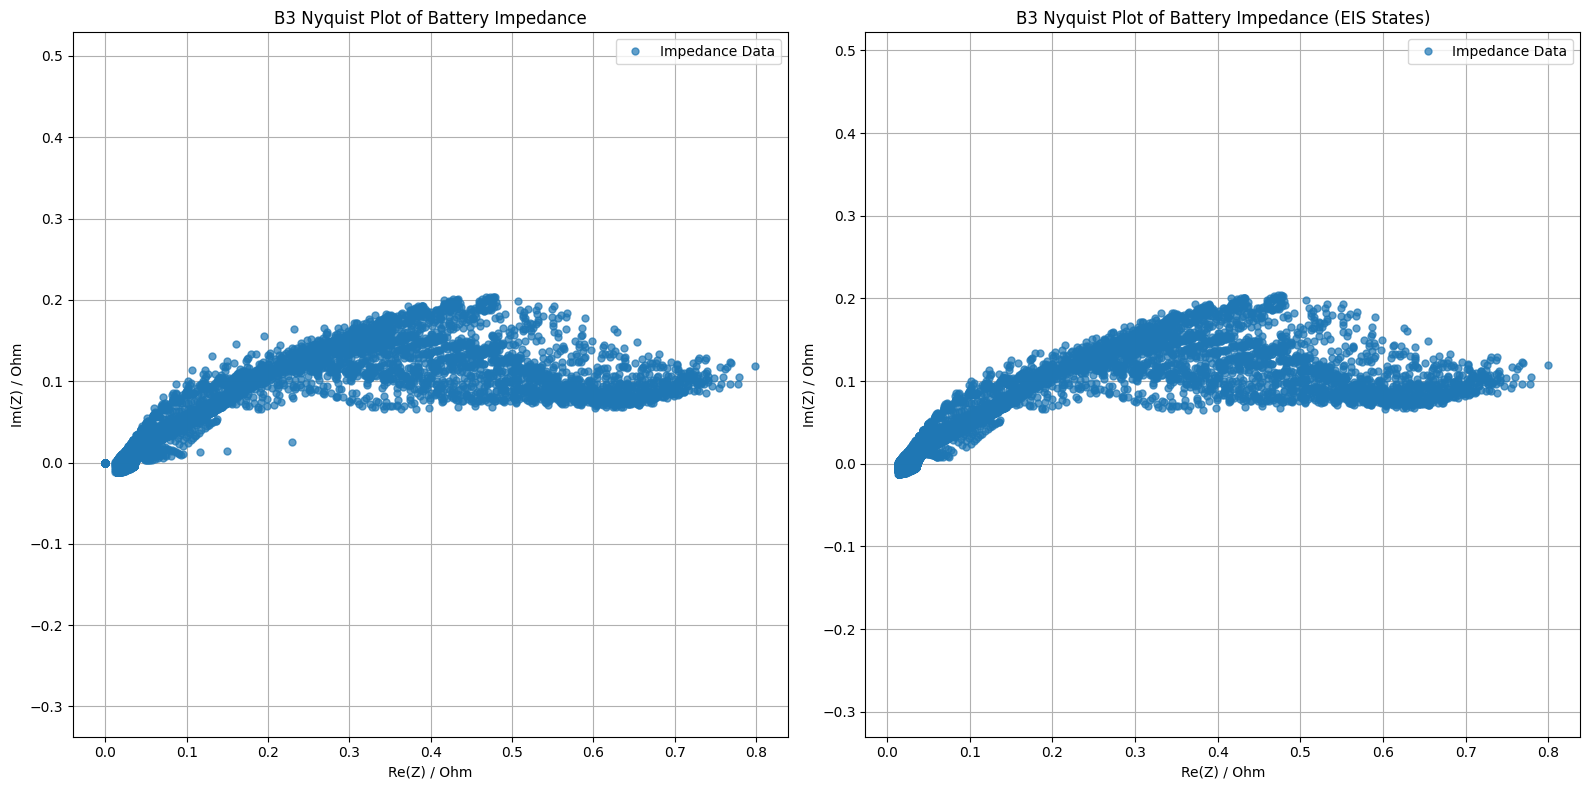

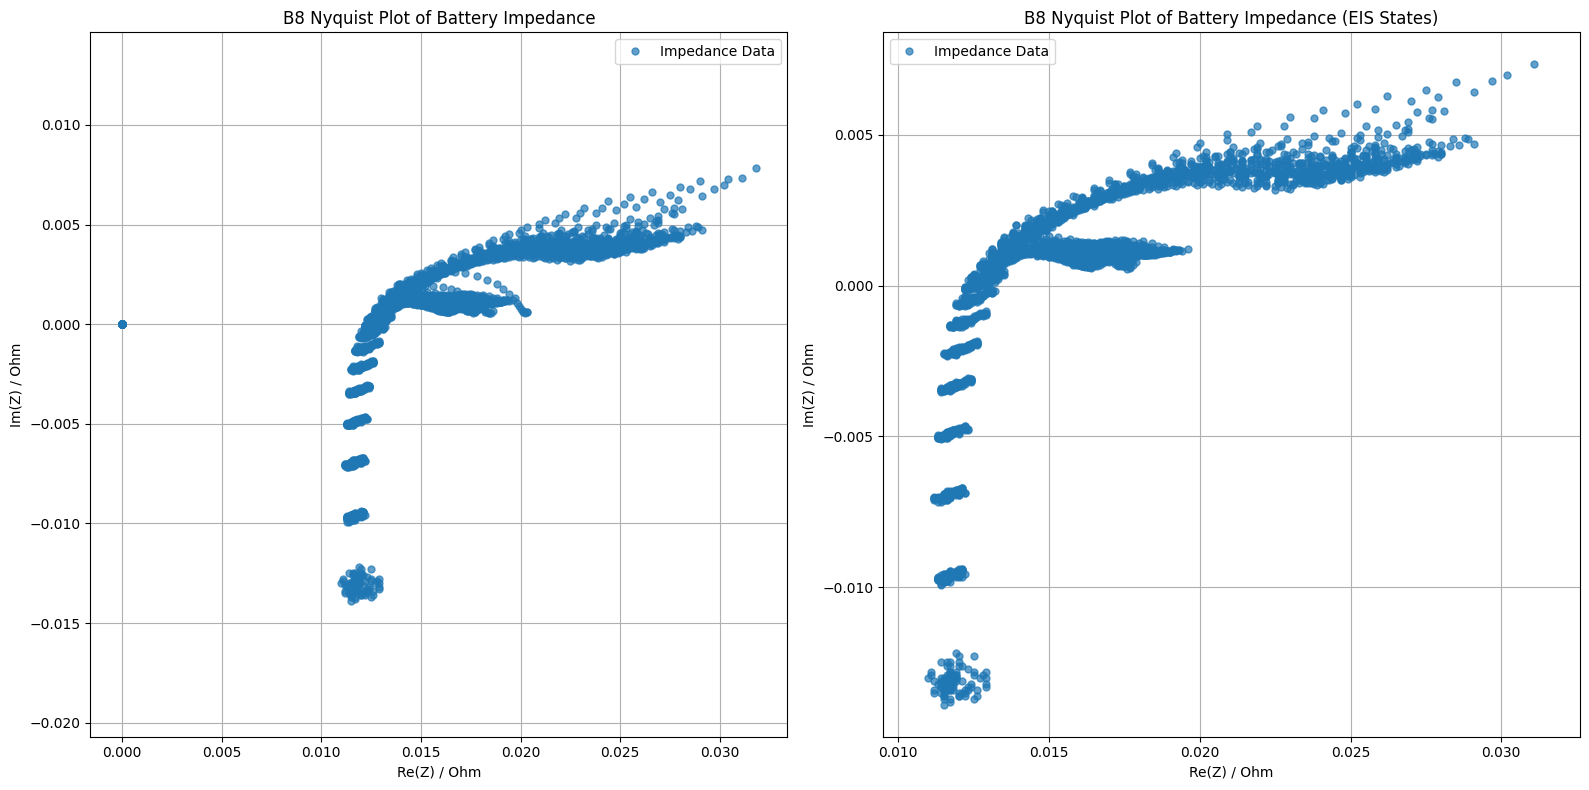

In [ ]:
data_folder = "../../data/03-22-24/"

channels = [
      f[:-4] for f in os.listdir(data_folder)
      if f.endswith('.csv')
]
    
for c in channels:
      df = data_pipeline.load_single_channel(data_folder, c)
      plots.nyquist(df, title_prefix=c)


## Nyquist Plot Analysis: Battery Degradation Insights

Analyzing what the Nyquist plots reveal about battery performance across different test conditions and degradation states.

In [ ]:
print("=== NYQUIST PLOT ANALYSIS: WHAT TO LOOK FOR ===\n")

print("🔋 KEY INSIGHTS FROM NYQUIST PLOTS:\n")

print("1. **SEMICIRCLE SIZE & SHAPE**:")
print("   • Larger semicircles = Higher charge transfer resistance")
print("   • Flattened/depressed semicircles = Non-ideal behavior, aging effects")
print("   • Multiple semicircles = Multiple electrochemical processes")

print("\n2. **X-AXIS INTERCEPTS**:")
print("   • Left intercept (high freq) = Series resistance (Rs)")
print("   • Right intercept (low freq) = Total resistance (Rs + Rct)")
print("   • Larger difference = Higher charge transfer resistance")

print("\n3. **DEGRADATION PATTERNS**:")
print("   • Fresh batteries: Small, well-defined semicircles")
print("   • Aged batteries: Larger, distorted semicircles")
print("   • Failed batteries: Very large resistance, poor semicircle definition")

print("\n4. **TEMPERATURE EFFECTS**:")
print("   • Low temperature: Larger semicircles (higher resistance)")
print("   • Room temperature: Smaller, more defined semicircles")

print("\n5. **C-RATE EFFECTS**:")
print("   • High C-rate cycling: More degradation, larger semicircles over time")
print("   • Low C-rate cycling: Less degradation, more stable impedance")

print("\n📊 COMPARISON FRAMEWORK:")
print("=" * 50)

print("\n**04/03/24 Dataset (A1-A8):**")
print("• High C-Rate, Room Temperature (25°C)")
print("• ~265 cycles, most channels FAILED")
print("• Expected: LARGE impedance, severely degraded Nyquist plots")
print("• Look for: Huge semicircles, poor definition, high series resistance")

print("\n**03/22/24 Dataset (B1-B8):**")
print("• Low C-Rate, Mix of temperatures")
print("• ~150 cycles, likely less degradation")
print("• B1-B4 (Low temp): Larger impedance due to temperature")
print("• B5-B8 (Room temp): Smaller impedance, better performance")

print("\n🎯 SPECIFIC ANALYSIS QUESTIONS:")
print("=" * 40)
print("1. Do A-channels show larger semicircles than B-channels?")
print("2. Are B1-B4 (low temp) semicircles larger than B5-B8 (room temp)?")
print("3. Which channels show the most degradation patterns?")
print("4. Do failed channels (A1,A2,A4,A5,A7,A8) have distinct Nyquist signatures?")
print("5. Are A3 and A6 (non-failed) different from other A-channels?")

print("\n💡 PHYSICS INTERPRETATION:")
print("=" * 30)
print("• Impedance growth = Active material loss, SEI thickening")
print("• Semicircle distortion = Non-uniform degradation, Li+ plating")
print("• High series resistance = Electrolyte degradation, contact issues")
print("• Temperature dependence = Kinetic limitations at low T")

## Quantitative Nyquist Analysis

Let's extract quantitative metrics from the Nyquist plots to compare degradation across channels.

In [ ]:
import pandas as pd
import numpy as np

def analyze_nyquist_metrics(df, channel_name):
    """Extract quantitative metrics from Nyquist data"""
    
    # Filter for EIS measurements (Ns = 1 or 6)
    eis_data = df[(df['Ns'].isin([1, 6])) & (df['cycle number'] != 0)].copy()
    
    if eis_data.empty:
        return None
    
    # Get impedance data
    Re_Z = eis_data['Re(Z)/Ohm'].values
    Im_Z = eis_data['Im(Z)/Ohm'].values
    
    # Calculate key metrics
    metrics = {
        'channel': channel_name,
        'series_resistance': Re_Z.min(),  # High frequency intercept
        'total_resistance': Re_Z.max(),   # Low frequency intercept  
        'charge_transfer_resistance': Re_Z.max() - Re_Z.min(),
        'max_imaginary': -Im_Z.min(),     # Peak of semicircle (negative because Im is negative)
        'impedance_range': Re_Z.max() - Re_Z.min(),
        'data_points': len(Re_Z),
        'mean_capacity': df['Capacity/mA.h'].mean() if 'Capacity/mA.h' in df.columns else None
    }
    
    return metrics

# Analyze both datasets
print("=== QUANTITATIVE NYQUIST ANALYSIS ===\n")

datasets = {
    "04/03/24 (High C-Rate, Failed)": "../../data/04-03-24/",
    "03/22/24 (Low C-Rate, Mixed Temp)": "../../data/03-22-24/"
}

all_metrics = []

for dataset_name, data_folder in datasets.items():
    print(f"📊 {dataset_name}")
    print("-" * 50)
    
    channels = [f[:-4] for f in os.listdir(data_folder) if f.endswith('.csv')]
    
    for channel in sorted(channels):
        try:
            df = data_pipeline.load_single_channel(data_folder, channel)
            metrics = analyze_nyquist_metrics(df, f"{dataset_name}_{channel}")
            
            if metrics:
                all_metrics.append(metrics)
                print(f"{channel}: Rs={metrics['series_resistance']:.3f}Ω, "
                      f"Rct={metrics['charge_transfer_resistance']:.3f}Ω, "
                      f"Total={metrics['total_resistance']:.3f}Ω")
        except Exception as e:
            print(f"{channel}: Error - {e}")
    
    print()

# Convert to DataFrame for easy analysis
if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    
    print("📈 COMPARATIVE ANALYSIS:")
    print("=" * 30)
    
    # Group by dataset
    for dataset in metrics_df['channel'].str.split('_').str[0].unique():
        dataset_metrics = metrics_df[metrics_df['channel'].str.startswith(dataset)]
        
        print(f"\n{dataset}:")
        print(f"  Average Series Resistance: {dataset_metrics['series_resistance'].mean():.3f} ± {dataset_metrics['series_resistance'].std():.3f}Ω")
        print(f"  Average Charge Transfer Resistance: {dataset_metrics['charge_transfer_resistance'].mean():.3f} ± {dataset_metrics['charge_transfer_resistance'].std():.3f}Ω")
        print(f"  Average Total Resistance: {dataset_metrics['total_resistance'].mean():.3f} ± {dataset_metrics['total_resistance'].std():.3f}Ω")
    
    # Compare failed vs non-failed (for A channels)
    a_channels = metrics_df[metrics_df['channel'].str.contains('04/03/24')].copy()
    if not a_channels.empty:
        a_channels['is_failed'] = ~a_channels['channel'].str.contains('_A[36]_')  # A3 and A6 didn't fail
        
        print(f"\n🔥 FAILED vs NON-FAILED A-CHANNELS:")
        if a_channels['is_failed'].sum() > 0 and (~a_channels['is_failed']).sum() > 0:
            failed = a_channels[a_channels['is_failed']]
            non_failed = a_channels[~a_channels['is_failed']]
            
            print(f"  Failed channels ({len(failed)}):")
            print(f"    Avg Total Resistance: {failed['total_resistance'].mean():.3f}Ω")
            print(f"  Non-failed channels ({len(non_failed)}):")
            print(f"    Avg Total Resistance: {non_failed['total_resistance'].mean():.3f}Ω")
            
            resistance_diff = failed['total_resistance'].mean() - non_failed['total_resistance'].mean()
            print(f"  Difference: {resistance_diff:.3f}Ω ({'Higher' if resistance_diff > 0 else 'Lower'} in failed)")

else:
    print("No valid metrics extracted.")

=== QUANTITATIVE NYQUIST ANALYSIS ===

📊 04/03/24 (High C-Rate, Failed)
--------------------------------------------------
A1: Rs=0.012Ω, Rct=0.032Ω, Total=0.043Ω
A2: Rs=0.012Ω, Rct=0.038Ω, Total=0.050Ω
A3: Rs=0.011Ω, Rct=0.036Ω, Total=0.048Ω
A4: Rs=0.011Ω, Rct=0.050Ω, Total=0.061Ω
A5: Rs=0.012Ω, Rct=0.109Ω, Total=0.121Ω
A6: Rs=0.011Ω, Rct=0.041Ω, Total=0.052Ω
A7: Rs=0.011Ω, Rct=0.101Ω, Total=0.112Ω
A8: Rs=0.011Ω, Rct=0.033Ω, Total=0.044Ω

📊 03/22/24 (Low C-Rate, Mixed Temp)
--------------------------------------------------
B1: Rs=0.013Ω, Rct=0.676Ω, Total=0.689Ω
B2: Rs=0.013Ω, Rct=0.694Ω, Total=0.706Ω
B3: Rs=0.013Ω, Rct=0.786Ω, Total=0.799Ω
B4: Rs=0.014Ω, Rct=0.833Ω, Total=0.847Ω
B5: Rs=0.012Ω, Rct=0.057Ω, Total=0.069Ω
B6: Rs=0.011Ω, Rct=0.063Ω, Total=0.074Ω
B7: Rs=0.011Ω, Rct=0.018Ω, Total=0.029Ω
B8: Rs=0.011Ω, Rct=0.020Ω, Total=0.031Ω

📈 COMPARATIVE ANALYSIS:

04/03/24 (High C-Rate, Failed):
  Average Series Resistance: 0.011 ± 0.000Ω
  Average Charge Transfer Resistance: 0.055 ± 0